In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
plt.style.use('ggplot')
import seaborn as sns
import requests
import wordcloud
import spacy
import os
import re
from dotenv import load_dotenv
from wordcloud import WordCloud
from collections import Counter
from bs4 import BeautifulSoup

In [15]:
def getListaPokemon(ruta):
    df = pd.read_csv(ruta, usecols=[1])
    df = df.iloc[:151,:]
    return df

In [16]:
def mapear_nombres(df, mapeo, semilla=42):
    rng = np.random.default_rng(seed=semilla)

    # Obtener nombres únicos
    nombres_unicos = df["nombre"].dropna().unique()

    # Obtener Pokémon disponibles
    pokemons = mapeo.dropna().to_numpy()

    # Validar que haya suficientes Pokémon
    if len(nombres_unicos) > len(pokemons):
        raise ValueError(
            f"Hay {len(nombres_unicos)} nombres únicos, "
            f"pero solo {len(pokemons)} Pokémon disponibles."
        )

    # Seleccionar Pokémon aleatoriamente sin repetición
    pokemons_aleatorios = rng.choice(
        pokemons,
        size=len(nombres_unicos),
        replace=False
    )

    # Crear diccionario:
    # nombre original -> Pokémon
    diccionario_mapeo = dict(
        zip(nombres_unicos, pokemons_aleatorios)
    )

    # Crear copia
    df_resultado = df.copy()

    # Mapear columna nombre
    df_resultado["nombre"] = (
        df_resultado["nombre"]
        .map(diccionario_mapeo)
    )

    # Función para reemplazar menciones dentro del mensaje
    def reemplazar_mencion(match):
        nombre_mencionado = match.group(1).strip()

        # Buscar ese nombre en el diccionario
        pokemon = diccionario_mapeo.get(nombre_mencionado)

        if pokemon is not None:
            return f"@{pokemon}"

        # Si no encontramos equivalencia, conservar la mención
        return match.group(0)

    # Reemplazar menciones tipo:
    df_resultado["mensaje"] = (
        df_resultado["mensaje"]
        .fillna("")
        .apply(
            lambda texto: re.sub(
                r"@\u2068(.*?)\u2069",
                reemplazar_mencion,
                texto
            )
        )
    )

    return df_resultado

In [17]:
# def limpiar_menciones(df):
#     df = df.copy()

#     df["mensaje"] = df["mensaje"].str.replace(
#         r"@.*?",
#         "@Mención",
#         regex=True
#     )

#     return df

In [18]:
load_dotenv()
data = os.getenv("DATA_PATH")
pkmn_map = os.getenv("CAT_PKMN_PATH")
# pkmn_map = '../data/raw/International List of Pokémon Names - Pokemon.csv'

patron = re.compile(
    r"^(\d{1,2}/\d{1,2}/\d{2,4}),\s+" # Captura de la fecha
    r"(\d{1,2}:\d{2})\s*([ap]\.?\s*m\.?)\s+-\s+" #  Captura de hora y contacto
    r"([^:]+):\s*(.*)$", # Mensaje
    re.IGNORECASE
)

registros = []

with open(data, "r", encoding="utf-8") as f:
    for linea in f:
        linea = linea.strip()

        match = patron.match(linea)

        if match:
            fecha, hora, periodo, nombre, mensaje = match.groups()

            registros.append({
                "fecha": fecha,
                "hora": hora,
                "periodo": periodo,
                "nombre": nombre.strip(),
                "mensaje": mensaje.strip()
            })

df = pd.DataFrame(registros)

In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 962 entries, 0 to 961
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   fecha    962 non-null    str  
 1   hora     962 non-null    str  
 2   periodo  962 non-null    str  
 3   nombre   962 non-null    str  
 4   mensaje  962 non-null    str  
dtypes: str(5)
memory usage: 37.7 KB


In [20]:
mapeo = getListaPokemon(pkmn_map)
mapeo.head()

,en
0,Bulbasaur
1,Ivysaur
2,Venusaur
3,Charmander
4,Charmeleon


In [21]:
df_map = mapear_nombres(
    df,
    mapeo,
    semilla=42
)
df_map.head()

,fecha,hora,periodo,nombre,mensaje
0,26/3/26,2:42,p. m.,[Mew],"Y otra cosa @['Magikarp'], @['Dragonite'] está..."
1,26/3/26,2:42,p. m.,[Mew],<Multimedia omitido>
2,26/3/26,2:44,p. m.,[Mew],Tenemos 2 dudas:
3,26/3/26,2:51,p. m.,[Magikarp],"No, los inactivos no me sirven para ningun rep..."
4,26/3/26,3:00,p. m.,[Magikarp],Respecto a los códigos que fueron *inhabilitad...


In [22]:
df_map["nombre"] = df_map["nombre"].apply(lambda x: x.item() if isinstance(x, np.ndarray) and x.size == 1 else str(x))
df_map.shape

(962, 5)

#### 1. ¿Cuál es el usuario que más mensajes envía?

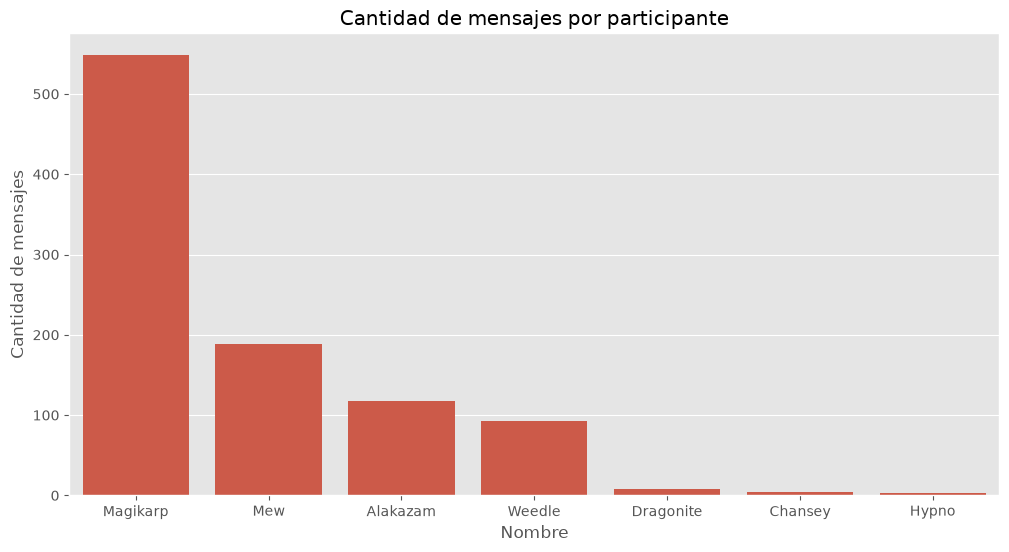

In [57]:
conteo = (df_map["nombre"].astype(str).value_counts())

plt.figure(figsize=(12, 6))
sns.barplot(x=conteo.index, y=conteo.values)
plt.xlabel("Nombre")
plt.ylabel("Cantidad de mensajes")
plt.title("Cantidad de mensajes por participante")
plt.show()

In [24]:
conteo = (df_map["nombre"].value_counts().reset_index())
conteo.columns = ["nombre", "cantidad"]
conteo["porcentaje"] = (conteo["cantidad"] / conteo["cantidad"].sum() * 100)

fig = px.bar(
    conteo,
    x="nombre",
    y="cantidad",
    title="Cantidad de mensajes por participante",
    labels={
        "nombre": "Nombre",
        "cantidad": "Cantidad de mensajes"
    },
    custom_data=["porcentaje"]
)

fig.update_traces(
    texttemplate="%{y}",
    textposition="outside",
    hovertemplate=(
        "<b>%{x}</b><br>"
        "Mensajes: %{y}<br>"
        "Participación: %{customdata[0]:.2f}%"
        "<extra></extra>"
    )
)

# Fix para que el las labesl no desborden del gráfico
max_valor = conteo["cantidad"].max()

fig.update_yaxes(
    range=[0, max_valor * 1.15]
)

fig.show()

#### ¿Cual es la frecuencia promedio de palabras por mensaje de texto de cada usuario?

In [25]:
# Contar palabras por mensaje
df_map["num_palabras"] = (
    df_map["mensaje"]
    .fillna("")
    .str.split()
    .str.len()
)

df_map.head()


,fecha,hora,periodo,nombre,mensaje,num_palabras
0,26/3/26,2:42,p. m.,Mew,"Y otra cosa @['Magikarp'], @['Dragonite'] está...",17
1,26/3/26,2:42,p. m.,Mew,<Multimedia omitido>,2
2,26/3/26,2:44,p. m.,Mew,Tenemos 2 dudas:,3
3,26/3/26,2:51,p. m.,Magikarp,"No, los inactivos no me sirven para ningun rep...",14
4,26/3/26,3:00,p. m.,Magikarp,Respecto a los códigos que fueron *inhabilitad...,38


In [26]:
# Normalizar a.m. / p.m.
periodo_normalizado = (
    df_map["periodo"]
    .str.lower()
    .str.replace(".", "", regex=False)
    .str.replace("\u202f", "", regex=False)  # espacio angosto Unicode
    .str.replace(" ", "", regex=False)
)

# Crear datetime
df_map["datetime"] = pd.to_datetime(
    df_map["fecha"] + " " +
    df_map["hora"] + " " +
    periodo_normalizado,
    format="%d/%m/%y %I:%M %p"
)

# Asignar zona horaria de Sonora
df_map["datetime"] = (
    df_map["datetime"]
    .dt.tz_localize("America/Hermosillo")
)

df_map.head()

,fecha,hora,periodo,nombre,mensaje,num_palabras,datetime
0,26/3/26,2:42,p. m.,Mew,"Y otra cosa @['Magikarp'], @['Dragonite'] está...",17,2026-03-26 14:42:00-07:00
1,26/3/26,2:42,p. m.,Mew,<Multimedia omitido>,2,2026-03-26 14:42:00-07:00
2,26/3/26,2:44,p. m.,Mew,Tenemos 2 dudas:,3,2026-03-26 14:44:00-07:00
3,26/3/26,2:51,p. m.,Magikarp,"No, los inactivos no me sirven para ningun rep...",14,2026-03-26 14:51:00-07:00
4,26/3/26,3:00,p. m.,Magikarp,Respecto a los códigos que fueron *inhabilitad...,38,2026-03-26 15:00:00-07:00


In [27]:
df_map.info()

<class 'pandas.DataFrame'>
RangeIndex: 962 entries, 0 to 961
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype                             
---  ------        --------------  -----                             
 0   fecha         962 non-null    str                               
 1   hora          962 non-null    str                               
 2   periodo       962 non-null    str                               
 3   nombre        962 non-null    str                               
 4   mensaje       962 non-null    str                               
 5   num_palabras  962 non-null    int64                             
 6   datetime      962 non-null    datetime64[us, America/Hermosillo]
dtypes: datetime64[us, America/Hermosillo](1), int64(1), str(5)
memory usage: 52.7 KB


In [28]:
df_map.drop(columns=['fecha', 'hora', 'periodo'], inplace=True)

In [29]:
df_map['hora'] = df_map['datetime'].dt.hour
df_map['Fecha'] = df_map['datetime'].dt.date
df_map.head()

,nombre,mensaje,num_palabras,datetime,hora,Fecha
0,Mew,"Y otra cosa @['Magikarp'], @['Dragonite'] está...",17,2026-03-26 14:42:00-07:00,14,2026-03-26
1,Mew,<Multimedia omitido>,2,2026-03-26 14:42:00-07:00,14,2026-03-26
2,Mew,Tenemos 2 dudas:,3,2026-03-26 14:44:00-07:00,14,2026-03-26
3,Magikarp,"No, los inactivos no me sirven para ningun rep...",14,2026-03-26 14:51:00-07:00,14,2026-03-26
4,Magikarp,Respecto a los códigos que fueron *inhabilitad...,38,2026-03-26 15:00:00-07:00,15,2026-03-26


In [30]:
#   Eliminar el <Multimedia omitido> para que no afecte al conteo de palabras por pensaje
df_texto = df_map[
    df_map["mensaje"].ne("<Multimedia omitido>")
].copy()

In [31]:
estadisticas_palabras = (
    df_texto
    .groupby("nombre")["num_palabras"]
    .agg(
        promedio="mean",
        mediana="median",
        minimo="min",
        maximo="max",
        total="sum"
    )
    .sort_values("promedio", ascending=False)
    .round(2)
)

estadisticas_palabras

,promedio,mediana,minimo,maximo,total
nombre,,,,,
Mew,13.71,9.0,1,75,2509
Magikarp,11.44,7.0,1,79,4610
Weedle,10.58,7.0,1,68,751
Dragonite,8.43,8.0,2,16,59
Chansey,7.00,7.0,7,7,7
Alakazam,4.95,4.0,1,39,535
Hypno,1.00,1.0,1,1,2


In [32]:
estadisticas_palabras['total'].sort_values(ascending=False)

nombre
Magikarp     4610
Mew          2509
Weedle        751
Alakazam      535
Dragonite      59
Chansey         7
Hypno           2
Name: total, dtype: int64

Si bien _Mew_ es quien escribe en promedio más palabras por mensaje, Magikarp es quien ha 

#### 3. ´¿Cuál es el usuario que más palabras envía? ¿Y el que envía más emojis? ¿Y el que envía más *stickers*?´

In [33]:
df_map[df_map["mensaje"] == "<Multimedia omitido>"].groupby("nombre").size().sort_values(ascending=False)


nombre
Magikarp     145
Weedle        22
Alakazam      10
Mew            5
Chansey        3
Dragonite      1
Hypno          1
dtype: int64

#### 4. ¿Que días de la semana se mandan más mensajes y cuales menos? ¿Hay un patron semanal? ¿Y por hora del día?

In [35]:
mensajes_hora = (
    df_map
    .set_index("datetime")
    .resample("1h")
    .size()
    .reset_index(name="cantidad")
)

mensajes_hora.head()

,datetime,cantidad
0,2026-03-26 14:00:00-07:00,4
1,2026-03-26 15:00:00-07:00,10
2,2026-03-26 16:00:00-07:00,0
3,2026-03-26 17:00:00-07:00,0
4,2026-03-26 18:00:00-07:00,0


In [36]:
fig = px.line(
    mensajes_hora,
    x="datetime",
    y="cantidad",
    markers=True,
    title="Flujo de mensajes por hora",
    labels={
        "datetime": "Fecha y hora",
        "cantidad": "Cantidad de mensajes"
    }
)

fig.update_traces(
    hovertemplate=(
        "<b>%{x|%d/%m/%Y %H:%M}</b><br>"
        "Mensajes: %{y}"
        "<extra></extra>"
    )
)

fig.show()

Los picos más pronunciados suelen ser en horario laboral de gobierno (7:00-15:00)

¿Cómo se vería si el análisis es por semana?

In [37]:
mensajes_dia = (
    df_map
    .set_index("datetime")
    .resample("1d")
    .size()
    .reset_index(name="cantidad")
)

mensajes_dia.head()

/tmp/ipykernel_9357/592197624.py:4: Pandas4Warning: 'd' is deprecated and will be removed in a future version, please use 'D' instead.
  .resample("1d")


,datetime,cantidad
0,2026-03-26 00:00:00-07:00,14
1,2026-03-27 00:00:00-07:00,31
2,2026-03-28 00:00:00-07:00,0
3,2026-03-29 00:00:00-07:00,0
4,2026-03-30 00:00:00-07:00,4


In [38]:
fig = px.line(
    mensajes_dia,
    x="datetime",
    y="cantidad",
    markers=True,
    title="Flujo de mensajes por día",
    labels={
        "datetime": "Fecha",
        "cantidad": "Cantidad de mensajes"
    }
)

# Fondo para días laborales
for fecha in mensajes_dia["datetime"]:
    if fecha.weekday() < 5:
        fig.add_vrect(
            x0=fecha,
            x1=fecha + pd.Timedelta(days=1),
            fillcolor="red",
            opacity=0.10,
            layer="below",
            line_width=0
        )

# Elemento de leyenda
fig.add_trace(
    go.Scatter(
        x=[None],
        y=[None],
        mode="markers",
        marker=dict(
            size=12,
            color="rgba(255, 0, 0, 0.10)",
            symbol="square"
        ),
        name="Semana laboral (lun-vie)",
        hoverinfo="skip"
    )
)

fig.update_traces(
    selector=dict(mode="lines+markers"),
    hovertemplate=(
        "<b>%{x|%d/%m/%Y}</b><br>"
        "Mensajes: %{y}"
        "<extra></extra>"
    )
)

fig.show()

In [39]:
# Cantidad de mensajes por fecha
mensajes_fecha = (
    df_map
    .set_index("datetime")
    .resample("1D")
    .size()
    .reset_index(name="cantidad")
)

# Día de la semana
mensajes_fecha["dia_semana"] = mensajes_fecha["datetime"].dt.day_name()

promedio_dia = (
    mensajes_fecha
    .groupby("dia_semana")["cantidad"]
    .mean()
    .reset_index(name="promedio_mensajes")
)

promedio_dia

,dia_semana,promedio_mensajes
0,Friday,9.346154
1,Monday,9.680000
2,Saturday,0.000000
3,Sunday,0.000000
4,Thursday,6.269231
5,Tuesday,5.280000
6,Wednesday,7.280000


In [40]:
orden_dias = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

promedio_dia["dia_semana"] = pd.Categorical(
    promedio_dia["dia_semana"],
    categories=orden_dias,
    ordered=True
)

promedio_dia = promedio_dia.sort_values("dia_semana")

In [41]:
fig = px.bar(
    promedio_dia,
    x="dia_semana",
    y="promedio_mensajes",
    title="Promedio de mensajes por día de la semana",
    labels={
        "dia_semana": "Día de la semana",
        "promedio_mensajes": "Promedio de mensajes"
    },
    text_auto=".1f"
)

fig.update_traces(
    hovertemplate=(
        "<b>%{x}</b><br>"
        "Promedio: %{y:.2f} mensajes"
        "<extra></extra>"
    )
)

fig.show()

In [42]:
# Cantidad de mensajes por fecha y hora
mensajes_fecha_hora = (
    df_map
    .set_index("datetime")
    .resample("1h")
    .size()
    .reset_index(name="cantidad")
)

# Extraer hora del día
mensajes_fecha_hora["hora"] = mensajes_fecha_hora["datetime"].dt.hour

# Promedio para cada una de las 24 horas
promedio_hora = (
    mensajes_fecha_hora
    .groupby("hora")["cantidad"]
    .mean()
    .reindex(range(24), fill_value=0)
    .reset_index(name="promedio_mensajes")
)

promedio_hora

,hora,promedio_mensajes
0,0,0.000000
1,1,0.000000
2,2,0.000000
3,3,0.000000
4,4,0.000000
5,5,0.000000
6,6,0.000000
7,7,0.051136
8,8,0.113636
9,9,0.596591


In [43]:
import plotly.graph_objects as go

fig = px.line(
    promedio_hora,
    x="hora",
    y="promedio_mensajes",
    markers=True,
    title="Promedio de mensajes por hora del día",
    labels={
        "hora": "Hora del día",
        "promedio_mensajes": "Promedio de mensajes"
    }
)

# Sombrear horario de oficina: 07:00 - 15:00
fig.add_vrect(
    x0=7,
    x1=15,
    fillcolor="red",
    opacity=0.15,
    layer="below",
    line_width=0
)

# Traza ficticia para agregar horario de oficina a la leyenda
fig.add_trace(
    go.Scatter(
        x=[None],
        y=[None],
        mode="markers",
        marker=dict(
            size=12,
            color="rgba(255, 0, 0, 0.15)",
            symbol="square"
        ),
        name="Horario de oficina (07:00–15:00)",
        hoverinfo="skip"
    )
)

# Mostrar las 24 horas en el eje X
fig.update_xaxes(
    tickmode="array",
    tickvals=list(range(24)),
    ticktext=[f"{h:02d}:00" for h in range(24)]
)

# Hover de la línea
fig.update_traces(
    selector=dict(mode="lines+markers"),
    hovertemplate=(
        "<b>Hora: %{x}:00</b><br>"
        "Promedio: %{y:.2f} mensajes"
        "<extra></extra>"
    )
)

fig.show()

Se ve que religiosamente se respetan los sábados y domingos en donde no se registra actividad; además, la mayoría de actividad en el grupo se realiza dentro del horario laboral que abarca de 7 de la mañana a 3 de la tarde. Sin embargo, también se registra actividad después de la hora de salida.

Otro aspecto curioso es la caída que se registra alrededor de las 11:00, a lo mejor los integrantes del otro equipo de trabajo tienen una reunión los martes a las 11:00 de la mañana, ya que es el día y la fecha que menos actividad se registra.

#### 5. ¿Que palabras son las más usadas por cada usuario? ¿Y en general? ¿Que palabras son las más usadas en el grupo que no sean *stop words*? 

In [44]:
nlp = spacy.load("es_core_news_sm")

top_palabras = {}

for nombre, grupo in df_texto.groupby("nombre"):

    texto = " ".join(
        grupo["mensaje"]
        .dropna()
        .astype(str)
        .tolist()
    )

    doc = nlp(texto)

    palabras = [
        token.lemma_.lower()
        for token in doc
        if (
            token.is_alpha
            and not token.is_stop
            and not token.is_punct
            and not token.is_space
        )
    ]

    top_palabras[nombre] = Counter(palabras).most_common(1)

top_palabras

{'Alakazam': [('checar', 10)],
 'Chansey': [('capacitación', 1)],
 'Dragonite': [('tarde', 3)],
 'Hypno': [('okey', 1)],
 'Magikarp': [('paaas', 25)],
 'Mew': [('reunión', 22)],
 'Weedle': [('gracias', 24)]}

In [45]:
# Convertir el diccionario a DataFrame
datos = []

for usuario, palabras in top_palabras.items():
    for palabra, frecuencia in palabras:
        datos.append({
            "usuario": usuario,
            "palabra": palabra,
            "frecuencia": frecuencia
        })

df_top_palabras = pd.DataFrame(datos)

df_top_palabras.head()

,usuario,palabra,frecuencia
0,Alakazam,checar,10
1,Chansey,capacitación,1
2,Dragonite,tarde,3
3,Hypno,okey,1
4,Magikarp,paaas,25


In [46]:
df_top_palabras = df_top_palabras.sort_values(
    "frecuencia",
    ascending=True
)

fig = px.bar(
    df_top_palabras,
    x="frecuencia",
    y="usuario",
    orientation="h",
    text="palabra",
    title="Palabra más utilizada por usuario",
    labels={
        "frecuencia": "Frecuencia",
        "usuario": "Usuario"
    },
    custom_data=["palabra"]
)

fig.update_traces(
    texttemplate="%{customdata[0]} (%{x})",
    textposition="outside",
    hovertemplate=(
        "<b>%{y}</b><br>"
        "Palabra: %{customdata[0]}<br>"
        "Frecuencia: %{x}"
        "<extra></extra>"
    )
)

fig.update_layout(
    yaxis_title=None
)

fig.show()

In [47]:
# Unir todos los mensajes
texto_chat = " ".join(
    df_texto["mensaje"]
    .dropna()
    .astype(str)
)

# Procesar con spaCy
doc = nlp(texto_chat)

# Filtrar y lematizar
palabras = [
    token.lemma_.lower()
    for token in doc
    if (
        token.is_alpha
        and not token.is_stop
        and not token.is_punct
        and not token.is_space
    )
]

# Calcular frecuencias
frecuencias = Counter(palabras)

frecuencias.most_common(20)

[('gracias', 47),
 ('laura', 39),
 ('paaas', 36),
 ('sistema', 36),
 ('reunión', 35),
 ('ok', 35),
 ('plataforma', 33),
 ('catálogo', 31),
 ('favor', 31),
 ('usuario', 28),
 ('información', 28),
 ('apoyar', 27),
 ('poder', 27),
 ('quedar', 26),
 ('hola', 25),
 ('dependencia', 22),
 ('correo', 22),
 ('aparecer', 22),
 ('material', 21),
 ('checar', 21)]

In [48]:
excluir = {
    "hola",
    "de",
    "y",
    "para",
    "la",
    "a",
    #   ...
}

frecuencias_limpias = {
    palabra: frecuencia
    for palabra, frecuencia in frecuencias.items()
    if palabra not in excluir
}

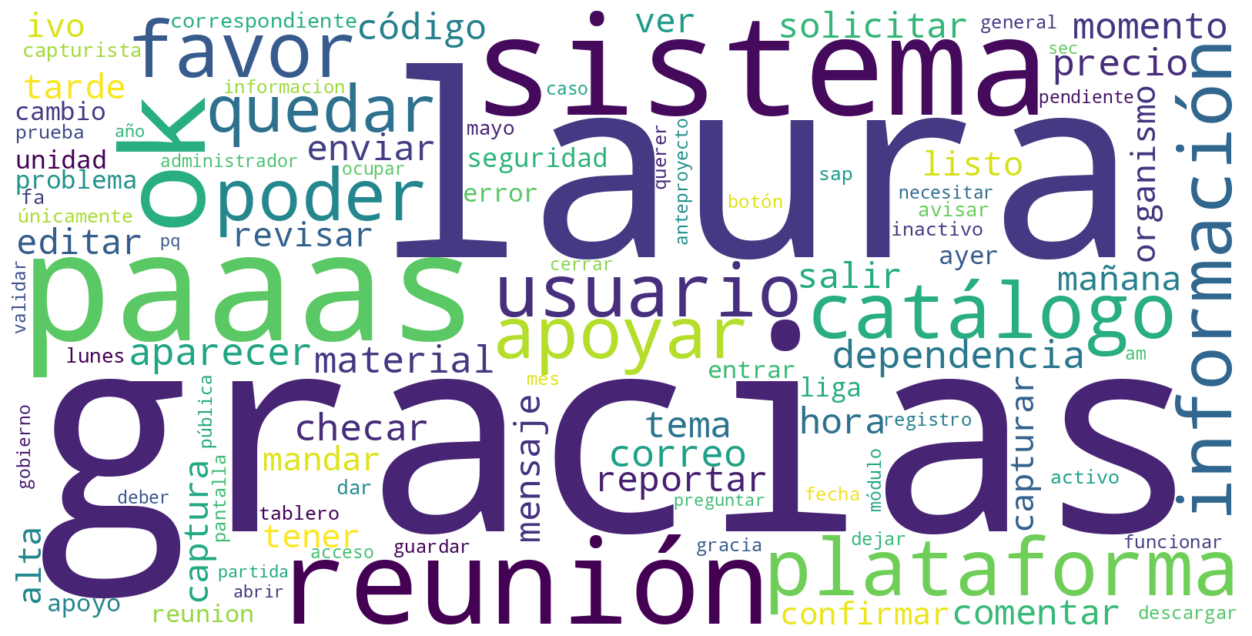

In [49]:
wordcloud = WordCloud(
    width=1600,
    height=800,
    background_color="white",
    max_words=100,
    collocations=False
).generate_from_frequencies(frecuencias_limpias)

plt.figure(figsize=(16, 8))

plt.imshow(
    wordcloud,
    interpolation="bilinear"
)

plt.axis("off")

plt.show()

La palabra más utilizada es "gracias", seguido de "laura" y "paaas". La palabra "favor" está significativamente reducida en tamaño al comparación del "gracias"

#### 6. ¿Cuales son los adjetivos más usados?

In [50]:
# Unir todos los mensajes
texto_chat = " ".join(
    df_texto["mensaje"]
    .dropna()
    .astype(str)
)

# Procesar con spaCy
doc = nlp(texto_chat)

# Extraer únicamente adjetivos
adjetivos = [
    token.lemma_.lower()
    for token in doc
    if (
        token.pos_ == "ADJ"
        and token.is_alpha
        and not token.is_stop
    )
]

# Contar frecuencias
frecuencia_adjetivos = Counter(adjetivos)

In [51]:
frecuencia_adjetivos

Counter({'correspondiente': 12,
         'activo': 8,
         'general': 8,
         'capturista': 7,
         'inactivo': 6,
         'necesario': 6,
         'disponible': 6,
         'usuario': 5,
         'privado': 5,
         'pendiente': 5,
         'único': 5,
         'atento': 5,
         'menor': 5,
         'listo': 5,
         'administrativo': 4,
         'cerrado': 4,
         'público': 4,
         'lento': 4,
         'conveniente': 4,
         'supremo': 3,
         'checo': 3,
         'administrador': 3,
         'registrado': 3,
         'correcto': 3,
         'alto': 3,
         'electrónico': 3,
         'inactivado': 2,
         'social': 2,
         'reflejado': 2,
         'interno': 2,
         'vigente': 2,
         'enviado': 2,
         'descargo': 2,
         'habilitado': 2,
         'próximo': 2,
         'mayor': 2,
         'reporto': 2,
         'gestor': 2,
         'verde': 2,
         'oficial': 2,
         'haciendo': 2,
         'ahorito': 2,


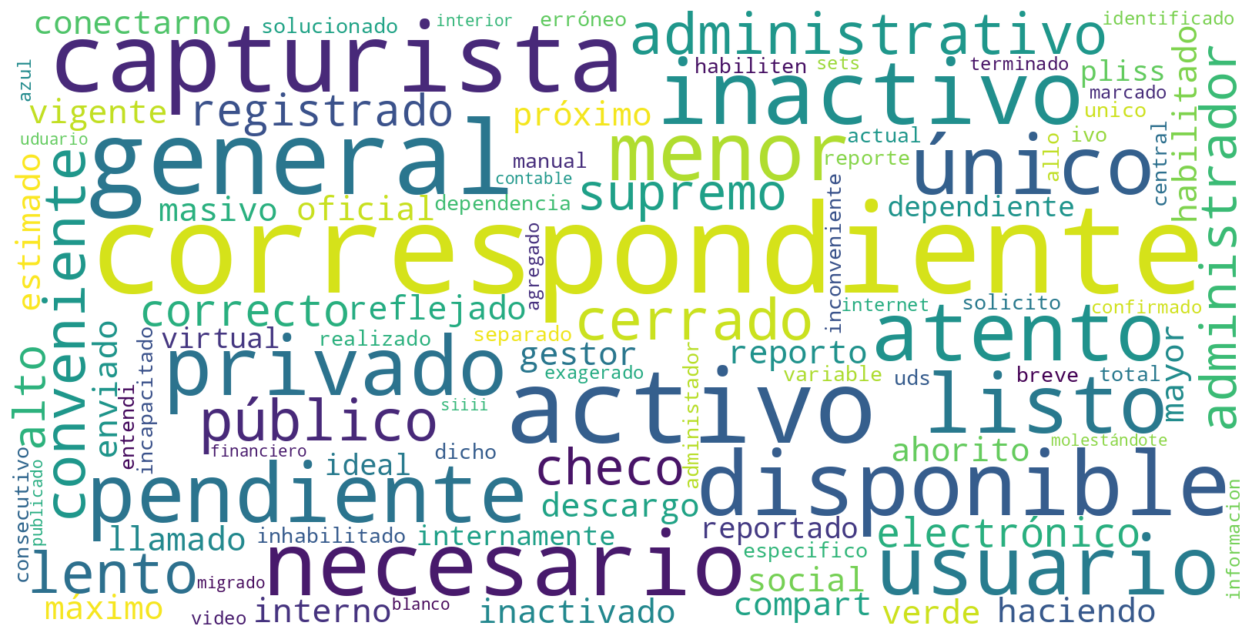

In [52]:
wordcloud = WordCloud(
    width=1600,
    height=800,
    background_color="white",
    max_words=100,
    collocations=False
).generate_from_frequencies(frecuencia_adjetivos)

plt.figure(figsize=(16, 8))

plt.imshow(
    wordcloud,
    interpolation="bilinear"
)

plt.axis("off")

plt.show()

---

### a. ¿Qué otras preguntas interesantes puedes responder con los datos que tienes? ¿Qué otras gráficas o análisis puedes hacer?

- Quién es la persona más etiquetada?
- ¿El mensaje más largo fue escrito con IA?


In [53]:
df_texto['mensaje'].head()

0    Y otra cosa @['Magikarp'], @['Dragonite'] está...
2                                     Tenemos 2 dudas:
3    No, los inactivos no me sirven para ningun rep...
4    Respecto a los códigos que fueron *inhabilitad...
5    Nos lo habían comentado en una de las últimas ...
Name: mensaje, dtype: str

In [54]:
# Extraer todas las menciones de cada mensaje
menciones = (
    df_texto["mensaje"]
    .str.findall(r"@\['([^']+)'\]")
    .explode()
    .dropna()
)

menciones.head()

0      Magikarp
0     Dragonite
30     Alakazam
74     Magikarp
74       Weedle
Name: mensaje, dtype: str

### b. Conclusiones

In [55]:
conteo_menciones = (
    menciones
    .value_counts()
    .reset_index()
)

conteo_menciones.columns = ["nombre", "menciones"]

conteo_menciones

,nombre,menciones
0,Magikarp,12
1,Mew,8
2,Alakazam,6
3,Weedle,6
4,Dragonite,2


In [56]:
menciones.shape

(34,)

In [ ]:
# df_map = limpiar_menciones(df_map)

In [ ]:
# df_map.to_csv('test.csv', index=False)